In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
# Dark Mode Plots
plt.style.use('dark_background')
import corner
import ast

In [25]:
# Make the corner plot for the MCMC results
system_name = 'HS0810'
model_ver = 'sie'
mcmc_samples_path = f'../{system_name}/mcmc/{model_ver}_mcmc.dat'
samples = pd.read_csv(mcmc_samples_path, delim_whitespace=True, header=None, names=['chi2', 'vel_disp', 'x', 'y', 'ellip', 'pa' ])


In [26]:
samples

,chi2,vel_disp,x,y,ellip,pa
6.048553,0.408600,163.2087,0.466918,0.166571,0.154013,-26.12184
6.586425,0.409395,163.2011,0.466264,0.166544,0.146162,-26.08770
6.563636,0.408109,163.2329,0.465845,0.168095,0.152841,-26.08397
12.155170,0.410364,163.2404,0.460618,0.168203,0.155115,-26.04541
19.161640,0.399126,163.2619,0.462403,0.162926,0.152678,-26.05329
...,...,...,...,...,...,...
11.201650,0.419925,163.7721,0.467589,0.164104,0.158555,-25.71524
12.897670,0.416187,163.7859,0.471564,0.168634,0.164137,-25.70689
11.231290,0.411982,163.7953,0.469303,0.165751,0.162477,-25.68740
14.794290,0.419873,163.7297,0.470130,0.165780,0.159403,-25.62883


In [27]:
masked_samples = samples.drop(columns=['chi2']).to_numpy()

In [28]:
# # Masked Samples with no accept column
# masked_samples = samples[samples['accept'] == 'accept'].copy()
# masked_samples = masked_samples.drop(columns=['accept', 'chi2']).to_numpy()
# masked_samples

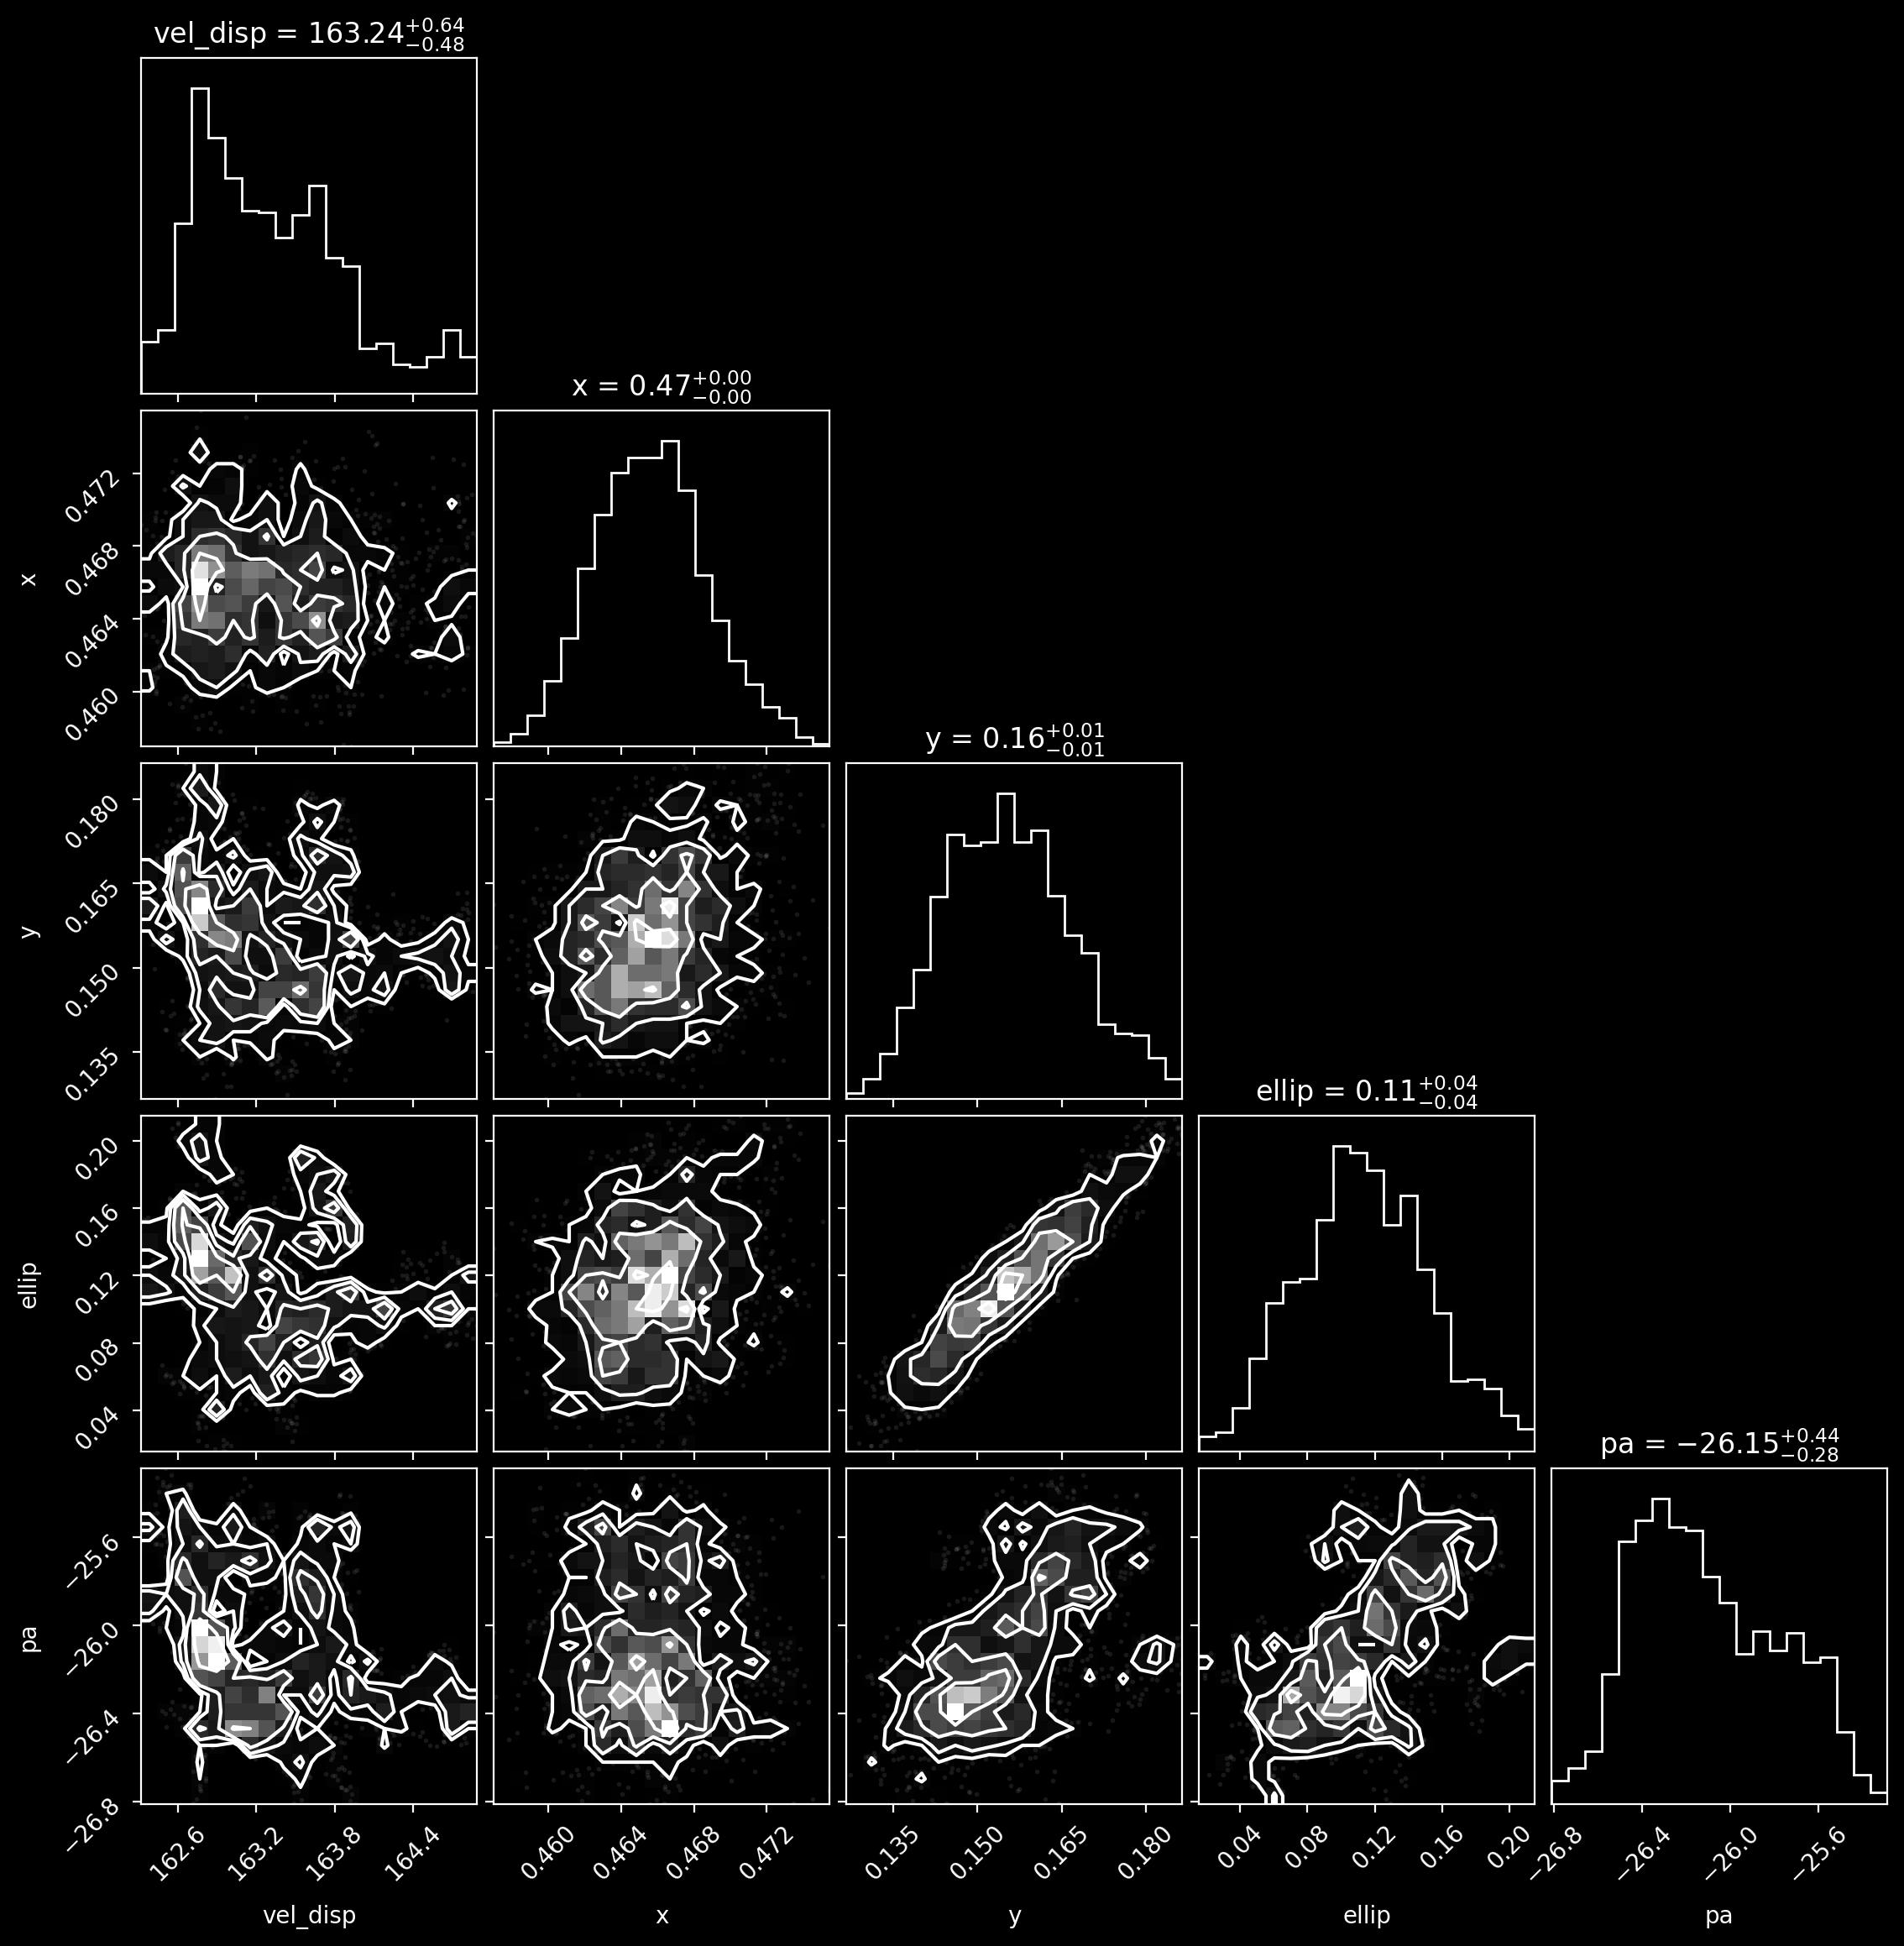

In [29]:
# Remove the first column when loading the samples, as it is the accepted/rejected column
labels = ['vel_disp', 'x', 'y', 'ellip', 'pa']
fig = corner.corner(masked_samples, labels=labels, show_titles=True)
plt.savefig(f'../{system_name}/mcmc/{model_ver}_corner.png')